In [46]:
!pip install shap

In [47]:
import shap
import numpy as np
import pandas as pd

print("SHAP version:", shap.__version__)
print("Explainability environment ready.")

SHAP version: 0.52.0
Explainability environment ready.


In [48]:
import os

data_path = "data"

print("Data path:", os.path.abspath(data_path))

Data path: c:\Users\namit\OneDrive\Desktop\AI_Bot_Detection\notebooks\data


In [49]:
# ==========================================
# STEP 2.1 — CHECK PROCESSED DATA
# ==========================================

processed_path = os.path.join(data_path, "processed")

print("PROCESSED FOLDER:")
for root, dirs, files in os.walk(processed_path):
    for file in files:
        print(os.path.join(root, file))

PROCESSED FOLDER:


In [50]:
import os
import pandas as pd

data_path = "../data"

behavior_features_path = os.path.join(
    data_path,
    "processed",
    "behavior_features.csv"
)

print("Looking for:", os.path.abspath(behavior_features_path))
print("Exists:", os.path.exists(behavior_features_path))

behavior_df = pd.read_csv(behavior_features_path)

print("Dataset shape:", behavior_df.shape)
print(behavior_df.head())

Looking for: c:\Users\namit\OneDrive\Desktop\AI_Bot_Detection\data\processed\behavior_features.csv
Exists: True
Dataset shape: (14368, 20)
           id      account_type  label  statuses_count  followers_count  \
0  1502026416  genuine_accounts      0            2177              208   
1  2492782375  genuine_accounts      0            2660              330   
2   293212315  genuine_accounts      0            1254              166   
3   191839658  genuine_accounts      0          202968             2248   
4  3020965143  genuine_accounts      0              82               21   

   friends_count  favourites_count  listed_count  \
0            332               265             1   
1            485              3972             5   
2            177              1185             0   
3            981             60304           101   
4             79                 5             0   

                       created_at              updated  account_age_days  \
0  Tue Jun 11 11:20:3

In [51]:
# ==========================================
# STEP 2.3 — DEFINE MODEL FEATURES
# ==========================================

behavior_feature_names = [
    "statuses_count",
    "followers_count",
    "friends_count",
    "favourites_count",
    "listed_count",
    "account_age_days",
    "statuses_per_day",
    "followers_friends_ratio",
    "friends_followers_ratio",
    "favorites_per_status",
    "log_statuses_count",
    "log_followers_count",
    "log_friends_count",
    "log_favourites_count",
    "log_listed_count"
]

print("Number of predictive features:", len(behavior_feature_names))

for i, feature in enumerate(behavior_feature_names, 1):
    print(f"{i}. {feature}")

Number of predictive features: 15
1. statuses_count
2. followers_count
3. friends_count
4. favourites_count
5. listed_count
6. account_age_days
7. statuses_per_day
8. followers_friends_ratio
9. friends_followers_ratio
10. favorites_per_status
11. log_statuses_count
12. log_followers_count
13. log_friends_count
14. log_favourites_count
15. log_listed_count


In [52]:
# ==========================================
# STEP 3 — DEFINE RESULTS PATH
# ==========================================

import os

final_results_path = os.path.join(
    "../data",
    "final_results"
)

print("Final results path:")
print(os.path.abspath(final_results_path))
print("Exists:", os.path.exists(final_results_path))

Final results path:
c:\Users\namit\OneDrive\Desktop\AI_Bot_Detection\data\final_results
Exists: True


In [53]:
# ==========================================
# DEFINE PROJECT PATH
# ==========================================

import os

project_path = ".."

print("PROJECT PATH:")
print(os.path.abspath(project_path))

PROJECT PATH:
c:\Users\namit\OneDrive\Desktop\AI_Bot_Detection


In [54]:
# ==========================================
# STEP 3 — CHECK SAVED MODEL FILES
# ==========================================

print("FINAL RESULTS FILES:")
for root, dirs, files in os.walk(final_results_path):
    for file in files:
        print(os.path.join(root, file))

print("\nPROJECT MODEL FILES:")

for root, dirs, files in os.walk(project_path):
    # Skip virtual environment and git folders
    dirs[:] = [
        d for d in dirs
        if d not in [".venv_nn", ".git", "__pycache__"]
    ]

    for file in files:
        if file.endswith((".keras", ".h5", ".pkl", ".joblib")):
            print(os.path.join(root, file))

FINAL RESULTS FILES:
../data\final_results\behavioral_common_test_results.csv
../data\final_results\behavioral_final_results.csv
../data\final_results\behavioral_lobo_test_results.csv
../data\final_results\behavioral_lobo_val_results.csv
../data\final_results\text_lobo_test_results.csv
../data\final_results\text_lobo_test_results_with_ids.csv
../data\final_results\text_lobo_val_results_with_ids.csv

PROJECT MODEL FILES:


In [55]:
# ==========================================
# STEP 3 — EXPLAINABILITY SETUP
# ==========================================

import os
import random
import numpy as np
import pandas as pd
import shap

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    BatchNormalization,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("SHAP version:", shap.__version__)
print("Random seed:", SEED)
print("Explainability setup ready.")

TensorFlow version: 2.21.0
SHAP version: 0.52.0
Random seed: 42
Explainability setup ready.


In [56]:
# ==========================================
# STEP 4 — CORRECT LOBO DATASET
# ==========================================

# Load full behavioral dataset
behavior_df = pd.read_csv(
    os.path.join(
        project_path,
        "data",
        "processed",
        "behavior_features.csv"
    )
)

behavior_features = [
    "statuses_count",
    "followers_count",
    "friends_count",
    "favourites_count",
    "listed_count",
    "account_age_days",
    "statuses_per_day",
    "followers_friends_ratio",
    "friends_followers_ratio",
    "favorites_per_status",
    "log_statuses_count",
    "log_followers_count",
    "log_friends_count",
    "log_favourites_count",
    "log_listed_count"
]

# The full matched 10,197-account population
# comes from the text-model dataset
text_full = pd.read_csv(
    os.path.join(
        project_path,
        "data",
        "text_model_predictions.csv"
    )
)

text_full = text_full.rename(columns={"user_id": "id"})

# Keep the matched account identity information
matched_accounts = text_full[
    ["id", "label", "account_type"]
].copy()

# Remove duplicate IDs if any
matched_accounts = matched_accounts.drop_duplicates("id")

# Merge with behavioral features
lobo_all = matched_accounts.merge(
    behavior_df[["id"] + behavior_features],
    on="id",
    how="inner"
)

print("Matched LOBO population:", lobo_all.shape)
print("Unique IDs:", lobo_all["id"].nunique())

print("\nAccount types:")
print(lobo_all["account_type"].value_counts())

print("\nLabels:")
print(lobo_all["label"].value_counts())

Matched LOBO population: (10197, 18)
Unique IDs: 10197

Account types:
account_type
social_spambots_2.csv         3457
fake_followers.csv            3202
genuine_accounts.csv          1083
traditional_spambots_1.csv    1000
social_spambots_1.csv          991
social_spambots_3.csv          464
Name: count, dtype: int64

Labels:
label
1    9114
0    1083
Name: count, dtype: int64


In [57]:
from sklearn.model_selection import train_test_split

In [58]:
# ==========================================
# STEP 5 — CORRECT LOBO TRAIN / TEST SPLIT
# ==========================================

# Remove ".csv" from account type names
lobo_all["account_type_clean"] = (
    lobo_all["account_type"]
    .astype(str)
    .str.replace(".csv", "", regex=False)
)

# Fake Followers = completely unseen
lobo_train = lobo_all[
    lobo_all["account_type_clean"] != "fake_followers"
].copy()

lobo_test = lobo_all[
    lobo_all["account_type_clean"].isin(
        ["fake_followers", "genuine_accounts"]
    )
].copy()

print("Training pool:", lobo_train.shape)
print("Unseen test pool:", lobo_test.shape)

print("\nTraining account types:")
print(lobo_train["account_type_clean"].value_counts())

print("\nTest account types:")
print(lobo_test["account_type_clean"].value_counts())

# 80/20 split of known training accounts
lobo_train_part, lobo_val = train_test_split(
    lobo_train,
    test_size=0.20,
    random_state=42,
    stratify=lobo_train["label"]
)

print("\nFinal split:")
print("Train:", lobo_train_part.shape)
print("Validation:", lobo_val.shape)
print("Test:", lobo_test.shape)

print("\nTrain labels:")
print(lobo_train_part["label"].value_counts())

print("\nValidation labels:")
print(lobo_val["label"].value_counts())

print("\nTest labels:")
print(lobo_test["label"].value_counts())

Training pool: (6995, 19)
Unseen test pool: (4285, 19)

Training account types:
account_type_clean
social_spambots_2         3457
genuine_accounts          1083
traditional_spambots_1    1000
social_spambots_1          991
social_spambots_3          464
Name: count, dtype: int64

Test account types:
account_type_clean
fake_followers      3202
genuine_accounts    1083
Name: count, dtype: int64

Final split:
Train: (5596, 19)
Validation: (1399, 19)
Test: (4285, 19)

Train labels:
label
1    4730
0     866
Name: count, dtype: int64

Validation labels:
label
1    1182
0     217
Name: count, dtype: int64

Test labels:
label
1    3202
0    1083
Name: count, dtype: int64


In [59]:
# ==========================================
# STEP 6 — BEHAVIORAL PREPROCESSING
# ==========================================

X_lobo_train = lobo_train_part[behavior_features].copy()
y_lobo_train = lobo_train_part["label"].copy()

X_lobo_val = lobo_val[behavior_features].copy()
y_lobo_val = lobo_val["label"].copy()

X_lobo_test = lobo_test[behavior_features].copy()
y_lobo_test = lobo_test["label"].copy()

# Median imputation — FIT ONLY ON TRAINING DATA
lobo_imputer = SimpleImputer(strategy="median")

X_lobo_train_imputed = lobo_imputer.fit_transform(
    X_lobo_train
)

X_lobo_val_imputed = lobo_imputer.transform(
    X_lobo_val
)

X_lobo_test_imputed = lobo_imputer.transform(
    X_lobo_test
)

# Standardization — FIT ONLY ON TRAINING DATA
lobo_scaler = StandardScaler()

X_lobo_train_scaled = lobo_scaler.fit_transform(
    X_lobo_train_imputed
)

X_lobo_val_scaled = lobo_scaler.transform(
    X_lobo_val_imputed
)

X_lobo_test_scaled = lobo_scaler.transform(
    X_lobo_test_imputed
)

print("Train:", X_lobo_train_scaled.shape)
print("Validation:", X_lobo_val_scaled.shape)
print("Test:", X_lobo_test_scaled.shape)

print("\nMissing values after imputation:")
print("Train:", np.isnan(X_lobo_train_scaled).sum())
print("Validation:", np.isnan(X_lobo_val_scaled).sum())
print("Test:", np.isnan(X_lobo_test_scaled).sum())

print("\nScaled feature means (first 5):")
print(X_lobo_train_scaled.mean(axis=0)[:5])

print("\nScaled feature stds (first 5):")
print(X_lobo_train_scaled.std(axis=0)[:5])

Train: (5596, 15)
Validation: (1399, 15)
Test: (4285, 15)

Missing values after imputation:
Train: 0
Validation: 0
Test: 0

Scaled feature means (first 5):
[ 1.52367992e-17 -6.34866633e-18 -6.34866633e-18  6.34866633e-18
  0.00000000e+00]

Scaled feature stds (first 5):
[1. 1. 1. 1. 1.]


In [60]:
# ==========================================
# STEP 7 — REBUILD BEHAVIORAL NEURAL NETWORK
# ==========================================

# Class weights used in the original LOBO model
lobo_class_weights = {
    0: 3.23094688221709,
    1: 0.5915433403805497
}

# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Exact architecture
lobo_behavior_nn_v2 = Sequential([
    Input(shape=(15,)),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.25),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.20),

    Dense(32, activation="relu"),
    Dropout(0.10),

    Dense(1, activation="sigmoid")
])

lobo_behavior_nn_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lobo_behavior_nn_v2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [61]:
# ==========================================
# STEP 8 — TRAIN RECONSTRUCTED LOBO MODEL
# ==========================================

early_stopping_lobo = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr_lobo = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history_lobo = lobo_behavior_nn_v2.fit(
    X_lobo_train_scaled,
    y_lobo_train,
    validation_data=(
        X_lobo_val_scaled,
        y_lobo_val
    ),
    epochs=50,
    batch_size=32,
    class_weight=lobo_class_weights,
    callbacks=[
        early_stopping_lobo,
        reduce_lr_lobo
    ],
    verbose=1
)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9564 - loss: 0.1499 - val_accuracy: 0.9893 - val_loss: 0.0770 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9830 - loss: 0.0729 - val_accuracy: 0.9886 - val_loss: 0.0418 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9841 - loss: 0.0601 - val_accuracy: 0.9878 - val_loss: 0.0415 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9839 - loss: 0.0602 - val_accuracy: 0.9878 - val_loss: 0.0429 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9861 - loss: 0.0507 - val_accuracy: 0.9886 - val_loss: 0.0427 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9862 - loss: 0.0460 - val_accuracy: 0.9878 - val_loss: 0.0414 - learning_rate: 5.0000e-04
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9857 - loss: 0.047

In [62]:
# ==========================================
# STEP 9 — VERIFY REBUILT MODEL
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predict on the completely unseen LOBO test set
behavior_lobo_test_prob_rebuilt = (
    lobo_behavior_nn_v2.predict(X_lobo_test, verbose=0)
    .ravel()
)

behavior_lobo_test_pred_rebuilt = (
    behavior_lobo_test_prob_rebuilt >= 0.5
).astype(int)

# Metrics
acc = accuracy_score(y_lobo_test, behavior_lobo_test_pred_rebuilt)
prec = precision_score(y_lobo_test, behavior_lobo_test_pred_rebuilt)
rec = recall_score(y_lobo_test, behavior_lobo_test_pred_rebuilt)
f1 = f1_score(y_lobo_test, behavior_lobo_test_pred_rebuilt)

print("REBUILT BEHAVIOR MODEL — UNSEEN FAKE FOLLOWERS")
print("=" * 55)
print(f"Accuracy : {acc:.4%}")
print(f"Precision: {prec:.4%}")
print(f"Recall   : {rec:.4%}")
print(f"F1 Score : {f1:.4%}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_lobo_test, behavior_lobo_test_pred_rebuilt))

print("\nClassification Report:")
print(
    classification_report(
        y_lobo_test,
        behavior_lobo_test_pred_rebuilt,
        target_names=["Genuine", "Bot"]
    )
)

REBUILT BEHAVIOR MODEL — UNSEEN FAKE FOLLOWERS
Accuracy : 70.2917%
Precision: 75.6448%
Recall   : 88.8507%
F1 Score : 81.7177%

Confusion Matrix:
[[ 167  916]
 [ 357 2845]]

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.32      0.15      0.21      1083
         Bot       0.76      0.89      0.82      3202

    accuracy                           0.70      4285
   macro avg       0.54      0.52      0.51      4285
weighted avg       0.65      0.70      0.66      4285



In [63]:
import tensorflow as tf
import joblib
import shap
import numpy as np
import pandas as pd

# Load the exact saved model
lobo_behavior_nn = tf.keras.models.load_model(
    "../models/lobo_behavior_nn_lobo.keras"
)

# Load the exact preprocessing used during training
lobo_imputer = joblib.load(
    "../models/lobo_behavior_imputer.joblib"
)

lobo_scaler = joblib.load(
    "../models/lobo_behavior_scaler.joblib"
)

print("Model loaded:", lobo_behavior_nn is not None)
print("Imputer loaded:", lobo_imputer is not None)
print("Scaler loaded:", lobo_scaler is not None)

Model loaded: True
Imputer loaded: True
Scaler loaded: True


In [64]:
# Exact behavioral features used by the model
feature_cols = [
    "statuses_count",
    "followers_count",
    "friends_count",
    "favourites_count",
    "listed_count",
    "account_age_days",
    "statuses_per_day",
    "followers_friends_ratio",
    "friends_followers_ratio",
    "favorites_per_status",
    "log_statuses_count",
    "log_followers_count",
    "log_friends_count",
    "log_favourites_count",
    "log_listed_count"
]

# Check that all features exist
missing_features = [col for col in feature_cols if col not in behavior_df.columns]

print("Missing features:", missing_features)
print("Number of features:", len(feature_cols))

Missing features: []
Number of features: 15


In [66]:
def predict_behavior_raw(X):
    """
    Takes raw behavioral features,
    applies the saved imputer and scaler,
    then returns bot probabilities.
    """
    X_df = pd.DataFrame(X, columns=feature_cols)

    X_imputed = lobo_imputer.transform(X_df)
    X_scaled = lobo_scaler.transform(X_imputed)

    return lobo_behavior_nn.predict(
        X_scaled, verbose=0
    ).ravel()


print("Prediction wrapper ready.")

Prediction wrapper ready.


In [67]:
# Test the wrapper on 5 accounts
test_sample = behavior_df[feature_cols].head(5)

test_probabilities = predict_behavior_raw(test_sample.values)

print("Test probabilities:")
print(test_probabilities)
print("Number of predictions:", len(test_probabilities))

Test probabilities:
[0.03280215 0.00669785 0.0073026  0.00825277 0.97823936]
Number of predictions: 5


In [68]:
# Use known training accounts as the SHAP background
# This prevents the unseen Fake Followers test set from influencing the background.

X_background = X_lobo_train[feature_cols].sample(
    n=50,
    random_state=42
)

print("SHAP background shape:", X_background.shape)
print("Background accounts:", len(X_background))

SHAP background shape: (50, 15)
Background accounts: 50


In [69]:
# Create SHAP KernelExplainer using the training background
explainer = shap.KernelExplainer(
    predict_behavior_raw,
    X_background.values
)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [70]:
# Explain a small sample from the unseen test set
X_explain = lobo_test[feature_cols].sample(
    n=50,
    random_state=42
)

print("Explanation sample shape:", X_explain.shape)

Explanation sample shape: (50, 15)


In [71]:
# Calculate SHAP values for the unseen test sample
shap_values = explainer.shap_values(
    X_explain.values,
    nsamples=100
)

print("SHAP calculation completed.")
print("SHAP values shape:", np.array(shap_values).shape)

100%|██████████| 50/50 [00:27<00:00,  1.84it/s]

SHAP calculation completed.
SHAP values shape: (50, 15)


In [72]:
# Convert SHAP values to a NumPy array
shap_array = np.array(shap_values)

# Calculate mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_array).mean(axis=0)

# Create feature-importance table
shap_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Mean_Absolute_SHAP": mean_abs_shap
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("SHAP Feature Importance:")
display(shap_importance)

SHAP Feature Importance:


,Feature,Mean_Absolute_SHAP
0,log_favourites_count,0.241877
1,account_age_days,0.057754
2,favorites_per_status,0.025288
3,friends_followers_ratio,0.024795
4,log_statuses_count,0.009330
5,log_friends_count,0.007104
6,log_followers_count,0.006516
7,statuses_per_day,0.006167
8,favourites_count,0.004935
9,friends_count,0.004113


In [74]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 2.6 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.3 MB 2.5 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.3 MB 2.6 MB/s eta 0:00:03
   ---------- ----------------------------- 2.4/9.3 MB 2.5 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.3 MB 2.4 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.3 MB 2.5 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.3 MB 2.5 MB/s eta 0:00:03
   -------------------- ------------------- 4.7/9.3 MB 2.6 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.3 MB 2.6 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/

In [75]:
import matplotlib.pyplot as plt

print("Matplotlib ready.")

Matplotlib ready.


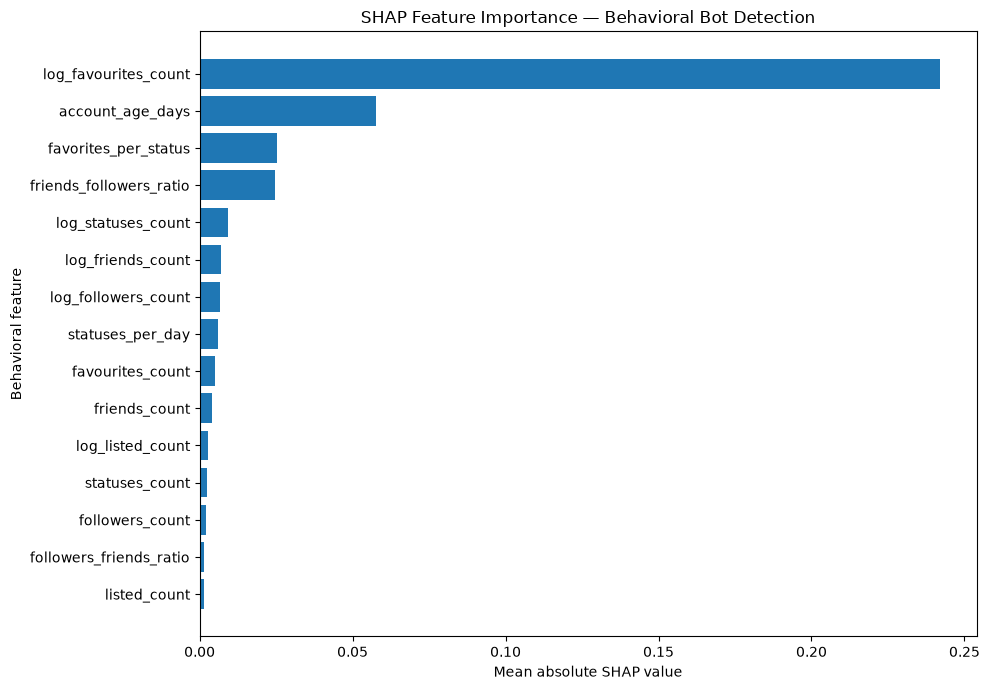

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate mean absolute SHAP importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create dataframe
shap_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Mean |SHAP|": mean_abs_shap
}).sort_values("Mean |SHAP|", ascending=True)

# Plot
plt.figure(figsize=(10, 7))
plt.barh(shap_importance["Feature"], shap_importance["Mean |SHAP|"])

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Behavioral feature")
plt.title("SHAP Feature Importance — Behavioral Bot Detection")

plt.tight_layout()
plt.show()

In [77]:
import shap
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_cols,
    plot_type="dot",
    show=True
)

ImportError: matplotlib is not installed so plotting is not available! Run `pip install matplotlib` to fix this.

In [78]:
import sys

!{sys.executable} -m pip install matplotlib

In [1]:
import matplotlib
import shap
import matplotlib.pyplot as plt

print("Matplotlib:", matplotlib.__version__)
print("SHAP:", shap.__version__)
print("Everything is ready.")

c:\Users\namit\OneDrive\Desktop\AI_Bot_Detection\.venv_nn\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Matplotlib: 3.11.1
SHAP: 0.52.0
Everything is ready.


In [3]:
print("Model:", "lobo_behavior_nn" in globals())
print("Feature list:", "feature_cols" in globals())
print("LOBO train:", "X_lobo_train" in globals())
print("LOBO test:", "lobo_test" in globals())

Model: False
Feature list: False
LOBO train: False
LOBO test: False


In [5]:
behavior_df = pd.read_csv("../data/processed/behavior_features.csv")

print("Behavior dataset:", behavior_df.shape)
print(behavior_df["account_type"].value_counts())

Behavior dataset: (14368, 20)
account_type
genuine_accounts          3474
social_spambots_2         3457
fake_followers            3351
traditional_spambots_4    1128
traditional_spambots_1    1000
social_spambots_1          991
social_spambots_3          464
traditional_spambots_3     403
traditional_spambots_2     100
Name: count, dtype: int64


In [6]:
feature_cols = [
    "statuses_count",
    "followers_count",
    "friends_count",
    "favourites_count",
    "listed_count",
    "account_age_days",
    "statuses_per_day",
    "followers_friends_ratio",
    "friends_followers_ratio",
    "favorites_per_status",
    "log_statuses_count",
    "log_followers_count",
    "log_friends_count",
    "log_favourites_count",
    "log_listed_count"
]

print("Number of features:", len(feature_cols))

Number of features: 15


In [7]:
lobo_behavior_nn = tf.keras.models.load_model(
    "../models/lobo_behavior_nn_lobo.keras"
)

lobo_imputer = joblib.load(
    "../models/lobo_behavior_imputer.joblib"
)

lobo_scaler = joblib.load(
    "../models/lobo_behavior_scaler.joblib"
)

print("Model loaded:", lobo_behavior_nn is not None)
print("Imputer loaded:", lobo_imputer is not None)
print("Scaler loaded:", lobo_scaler is not None)

Model loaded: True
Imputer loaded: True
Scaler loaded: True


In [4]:
import os
import random
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import shap
import matplotlib.pyplot as plt

print("Libraries loaded.")

Libraries loaded.


In [8]:
lobo_train_part = behavior_df[
    behavior_df["account_type"] != "fake_followers"
].copy()

lobo_test = behavior_df[
    behavior_df["account_type"].isin(
        ["fake_followers", "genuine_accounts"]
    )
].copy()

print("LOBO training pool:", lobo_train_part.shape)
print("LOBO test set:", lobo_test.shape)

print("\nTraining types:")
print(lobo_train_part["account_type"].value_counts())

print("\nTest types:")
print(lobo_test["account_type"].value_counts())

LOBO training pool: (11017, 20)
LOBO test set: (6825, 20)

Training types:
account_type
genuine_accounts          3474
social_spambots_2         3457
traditional_spambots_4    1128
traditional_spambots_1    1000
social_spambots_1          991
social_spambots_3          464
traditional_spambots_3     403
traditional_spambots_2     100
Name: count, dtype: int64

Test types:
account_type
genuine_accounts    3474
fake_followers      3351
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

X_lobo_train_part, X_lobo_val, y_lobo_train_part, y_lobo_val = train_test_split(
    lobo_train_part[feature_cols],
    lobo_train_part["label"],
    test_size=0.20,
    random_state=42,
    stratify=lobo_train_part["label"]
)

print("Training:", X_lobo_train_part.shape)
print("Validation:", X_lobo_val.shape)

Training: (8813, 15)
Validation: (2204, 15)


In [10]:
def predict_behavior_raw(X):
    X_df = pd.DataFrame(X, columns=feature_cols)

    X_imputed = lobo_imputer.transform(X_df)
    X_scaled = lobo_scaler.transform(X_imputed)

    return lobo_behavior_nn.predict(
        X_scaled,
        verbose=0
    ).ravel()

print("Prediction wrapper ready.")

Prediction wrapper ready.


In [11]:
X_background = X_lobo_train_part[
    feature_cols
].sample(
    n=50,
    random_state=42
)

print("SHAP background shape:", X_background.shape)

SHAP background shape: (50, 15)


In [12]:
X_explain = lobo_test[
    feature_cols
].sample(
    n=50,
    random_state=42
)

print("Accounts being explained:", X_explain.shape)

Accounts being explained: (50, 15)


In [13]:
explainer = shap.KernelExplainer(
    predict_behavior_raw,
    X_background.values
)

print("SHAP KernelExplainer ready.")

SHAP KernelExplainer ready.


In [14]:
shap_values = explainer.shap_values(
    X_explain.values,
    nsamples=100
)

shap_values = np.asarray(shap_values)

print("SHAP values shape:", shap_values.shape)

100%|██████████| 50/50 [00:32<00:00,  1.56it/s]

SHAP values shape: (50, 15)


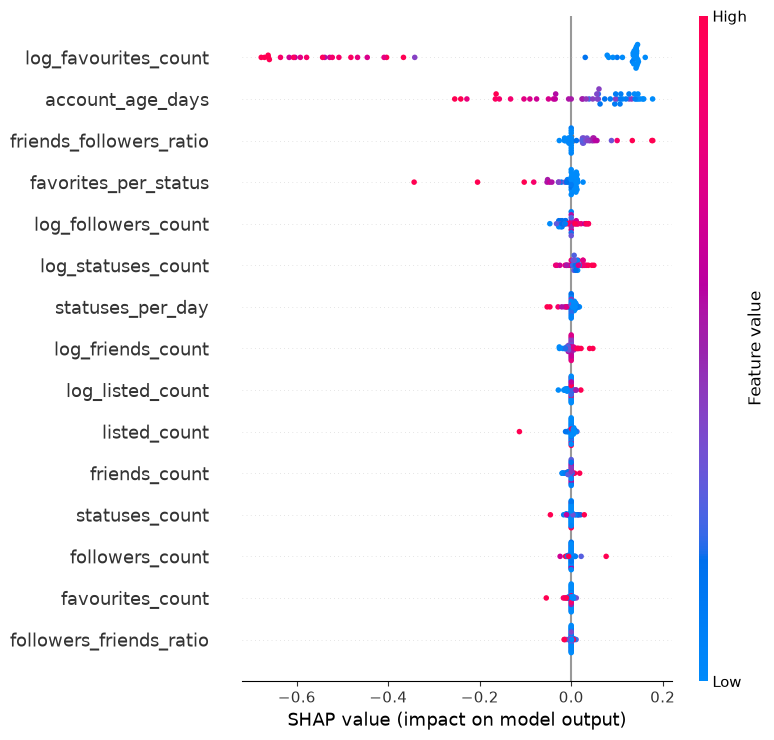

In [15]:
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_cols,
    plot_type="dot"
)

In [16]:
X_explain_200 = lobo_test[
    feature_cols
].sample(
    n=200,
    random_state=42
)

print("Accounts being explained:", X_explain_200.shape)

Accounts being explained: (200, 15)


In [17]:
shap_values_200 = explainer.shap_values(
    X_explain_200.values,
    nsamples=100
)

shap_values_200 = np.asarray(shap_values_200)

print("SHAP values shape:", shap_values_200.shape)

100%|██████████| 200/200 [02:02<00:00,  1.64it/s]

SHAP values shape: (200, 15)


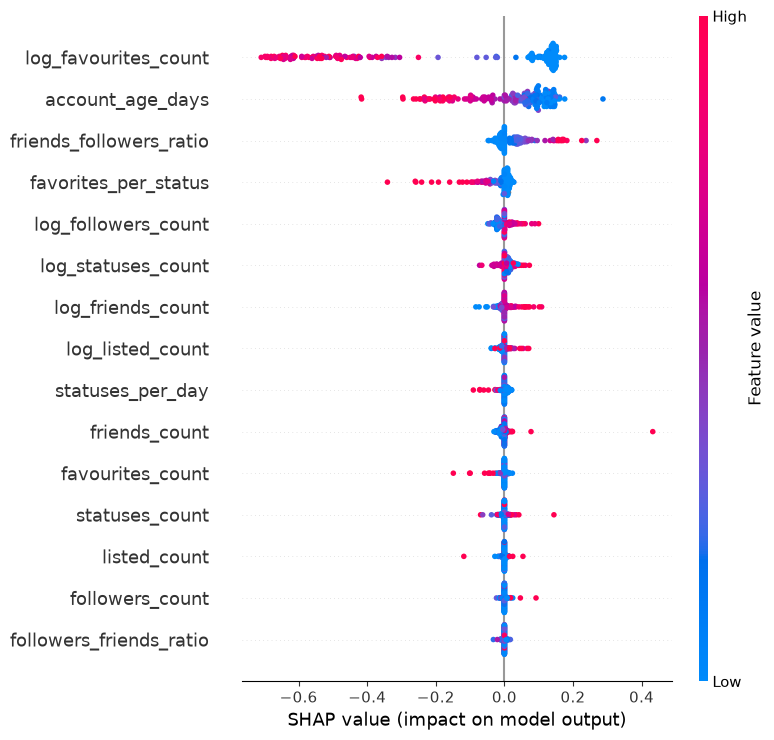

In [18]:
shap.summary_plot(
    shap_values_200,
    X_explain_200,
    feature_names=feature_cols,
    plot_type="dot"
)

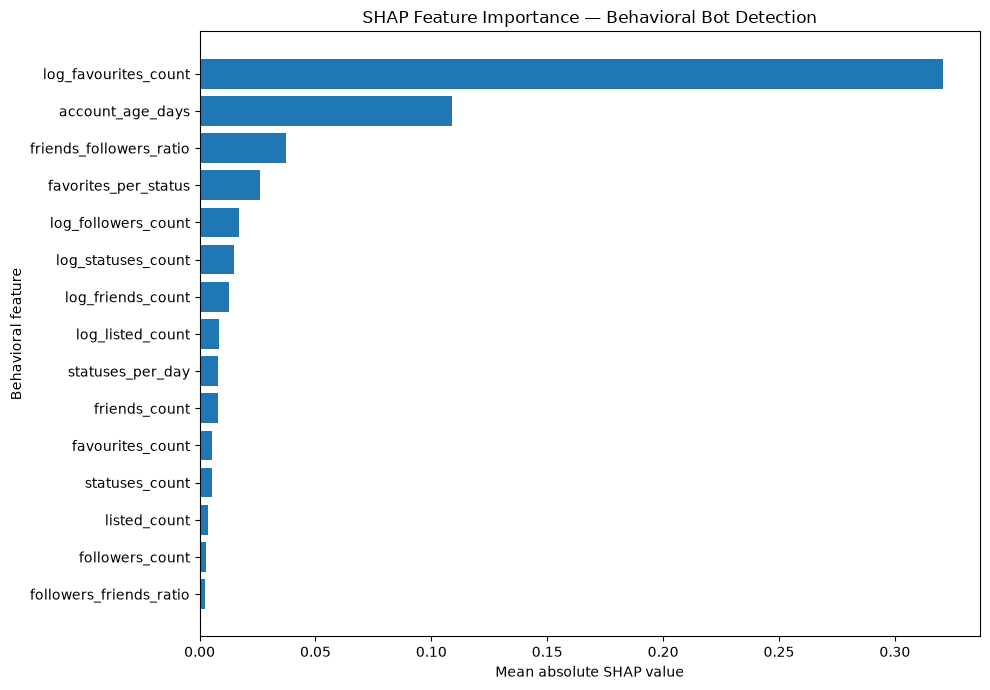

In [19]:
mean_abs_shap_200 = np.abs(shap_values_200).mean(axis=0)

shap_importance_200 = pd.DataFrame({
    "Feature": feature_cols,
    "Mean |SHAP|": mean_abs_shap_200
}).sort_values("Mean |SHAP|", ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    shap_importance_200["Feature"],
    shap_importance_200["Mean |SHAP|"]
)

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Behavioral feature")
plt.title("SHAP Feature Importance — Behavioral Bot Detection")

plt.tight_layout()
plt.show()

In [20]:
# Get behavioral probabilities for the complete unseen LOBO test set
test_probabilities = predict_behavior_raw(
    lobo_test[feature_cols]
)

# Add probabilities temporarily
lobo_test_explain = lobo_test.copy()
lobo_test_explain["bot_probability"] = test_probabilities
lobo_test_explain["prediction"] = (
    lobo_test_explain["bot_probability"] >= 0.5
).astype(int)

# Select a high-confidence correctly predicted bot
example_candidates = lobo_test_explain[
    (lobo_test_explain["label"] == 1) &
    (lobo_test_explain["prediction"] == 1)
].sort_values(
    "bot_probability",
    ascending=False
)

example_account = example_candidates.iloc[0]

print("Example account:")
print("User ID:", example_account["id"])
print("Actual label:", example_account["label"])
print("Bot probability:", round(example_account["bot_probability"], 4))
print("Prediction:", "BOT" if example_account["prediction"] == 1 else "GENUINE")

Example account:
User ID: 215154980
Actual label: 1
Bot probability: 1.0
Prediction: BOT


In [21]:
# Extract the account's behavioral features
X_example_account = example_account[feature_cols].to_frame().T

# Calculate SHAP values
shap_values_account = explainer.shap_values(
    X_example_account.values,
    nsamples=100
)

shap_values_account = np.asarray(shap_values_account)

print("SHAP shape:", shap_values_account.shape)

100%|██████████| 1/1 [00:00<00:00,  1.38it/s]

SHAP shape: (1, 15)


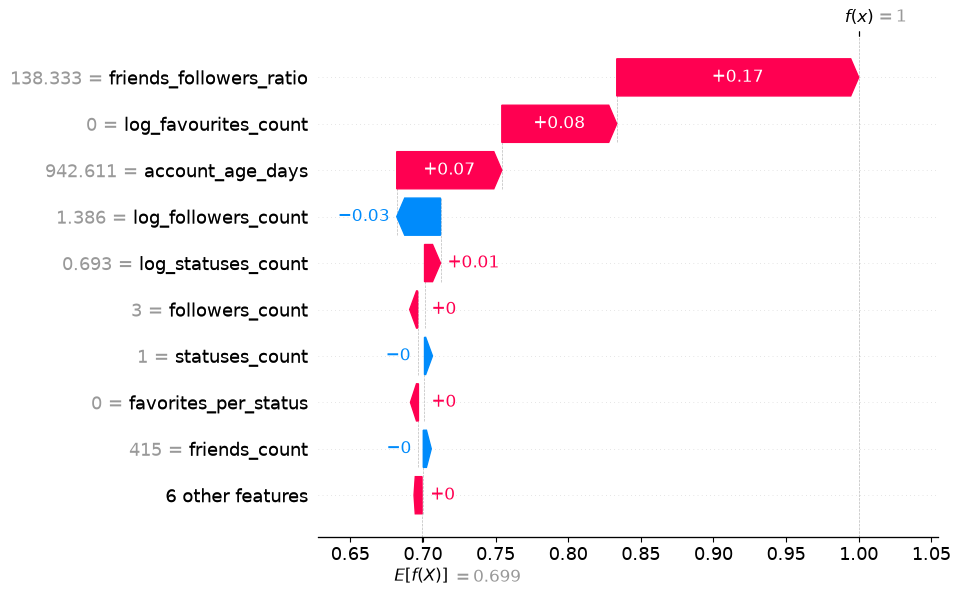

In [22]:
# Create SHAP Explanation object
account_explanation = shap.Explanation(
    values=shap_values_account[0],
    base_values=float(np.asarray(explainer.expected_value).reshape(-1)[0]),
    data=X_example_account.iloc[0].values,
    feature_names=feature_cols
)

# Display individual explanation
shap.plots.waterfall(
    account_explanation,
    max_display=10
)

In [23]:
# Create a table of individual feature contributions
individual_shap = pd.DataFrame({
    "Feature": feature_cols,
    "Feature Value": X_example_account.iloc[0].values,
    "SHAP Value": shap_values_account[0]
})

individual_shap["Direction"] = np.where(
    individual_shap["SHAP Value"] > 0,
    "Pushes toward BOT",
    "Pushes toward GENUINE"
)

individual_shap["Absolute SHAP"] = np.abs(
    individual_shap["SHAP Value"]
)

individual_shap = individual_shap.sort_values(
    "Absolute SHAP",
    ascending=False
)

display(
    individual_shap[
        ["Feature", "Feature Value", "SHAP Value", "Direction"]
    ].head(10)
)

,Feature,Feature Value,SHAP Value,Direction
8,friends_followers_ratio,138.333333,0.166570,Pushes toward BOT
13,log_favourites_count,0.0,0.079115,Pushes toward BOT
5,account_age_days,942.611042,0.072337,Pushes toward BOT
11,log_followers_count,1.386294,-0.030155,Pushes toward GENUINE
10,log_statuses_count,0.693147,0.011010,Pushes toward BOT
1,followers_count,3,0.004733,Pushes toward BOT
0,statuses_count,1,-0.004700,Pushes toward GENUINE
9,favorites_per_status,0.0,0.004169,Pushes toward BOT
2,friends_count,415,-0.003333,Pushes toward GENUINE
7,followers_friends_ratio,0.007229,0.000850,Pushes toward BOT


In [24]:
# ============================================================
# EXPLAINABLE BOT FLAG
# ============================================================

# Get prediction information
bot_probability = float(example_account["bot_probability"])
prediction = int(example_account["prediction"])

# Get top 5 strongest SHAP contributors
top_reasons = individual_shap.head(5).copy()

print("=" * 60)
print("        EXPLAINABLE BOT DETECTION RESULT")
print("=" * 60)

print(f"\nUser ID: {example_account['id']}")
print(f"Prediction: {'BOT' if prediction == 1 else 'GENUINE'}")
print(f"Bot Probability: {bot_probability:.2%}")

print("\nTop contributing behavioral factors:")

for _, row in top_reasons.iterrows():

    direction = (
        "toward BOT"
        if row["SHAP Value"] > 0
        else "toward GENUINE"
    )

    print(
        f"  • {row['Feature']}: "
        f"value={row['Feature Value']:.3f} "
        f"→ {direction} "
        f"(SHAP={row['SHAP Value']:+.3f})"
    )

print("\nRecommendation:")

if prediction == 1:
    print("  🚨 FLAG FOR BOT REVIEW")
else:
    print("  ✅ LIKELY GENUINE")

print("=" * 60)

        EXPLAINABLE BOT DETECTION RESULT

User ID: 215154980
Prediction: BOT
Bot Probability: 100.00%

Top contributing behavioral factors:
  • friends_followers_ratio: value=138.333 → toward BOT (SHAP=+0.167)
  • log_favourites_count: value=0.000 → toward BOT (SHAP=+0.079)
  • account_age_days: value=942.611 → toward BOT (SHAP=+0.072)
  • log_followers_count: value=1.386 → toward GENUINE (SHAP=-0.030)
  • log_statuses_count: value=0.693 → toward BOT (SHAP=+0.011)

Recommendation:
  🚨 FLAG FOR BOT REVIEW


In [25]:
# Save global SHAP importance
shap_importance_200 = pd.DataFrame({
    "Feature": feature_cols,
    "Mean_Absolute_SHAP": np.abs(shap_values_200).mean(axis=0)
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

shap_importance_200.to_csv(
    "../data/final_results/shap_feature_importance.csv",
    index=False
)

print("Saved:", "../data/final_results/shap_feature_importance.csv")
print(shap_importance_200)

Saved: ../data/final_results/shap_feature_importance.csv
                    Feature  Mean_Absolute_SHAP
13     log_favourites_count            0.320701
5          account_age_days            0.108996
8   friends_followers_ratio            0.037197
9      favorites_per_status            0.026051
11      log_followers_count            0.017173
10       log_statuses_count            0.014660
12        log_friends_count            0.012603
14         log_listed_count            0.008304
6          statuses_per_day            0.007894
2             friends_count            0.007775
3          favourites_count            0.005478
0            statuses_count            0.005389
4              listed_count            0.003434
1           followers_count            0.002944
7   followers_friends_ratio            0.002189


In [26]:
individual_shap.to_csv(
    "../data/final_results/individual_shap_explanation.csv",
    index=False
)

print("Individual SHAP explanation saved.")

Individual SHAP explanation saved.


In [27]:
print("=" * 60)
print("        EXPLAINABILITY SUMMARY")
print("=" * 60)

print("\nSHAP analysis:")
print("• Background accounts:", len(X_background))
print("• Explained test accounts:", len(X_explain_200))
print("• Behavioral features:", len(feature_cols))

print("\nTop 5 behavioral features:")
for i, row in shap_importance_200.head(5).reset_index(drop=True).iterrows():
    print(
        f"{i+1}. {row['Feature']} "
        f"(Mean |SHAP| = {row['Mean_Absolute_SHAP']:.4f})"
    )

print("\nIndividual example:")
print("• User ID:", example_account["id"])
print("• Actual:", "BOT" if example_account["label"] == 1 else "GENUINE")
print("• Prediction:", "BOT" if example_account["prediction"] == 1 else "GENUINE")
print(f"• Bot probability: {example_account['bot_probability']:.2%}")

print("\nExplainability module completed.")

        EXPLAINABILITY SUMMARY

SHAP analysis:
• Background accounts: 50
• Explained test accounts: 200
• Behavioral features: 15

Top 5 behavioral features:
1. log_favourites_count (Mean |SHAP| = 0.3207)
2. account_age_days (Mean |SHAP| = 0.1090)
3. friends_followers_ratio (Mean |SHAP| = 0.0372)
4. favorites_per_status (Mean |SHAP| = 0.0261)
5. log_followers_count (Mean |SHAP| = 0.0172)

Individual example:
• User ID: 215154980
• Actual: BOT
• Prediction: BOT
• Bot probability: 100.00%

Explainability module completed.
